 PROJET : Régression Linéaire, Multiple & Polynomiale

🔹 1. RÉGRESSION LINÉAIRE SIMPLE (1 feature)
 Linéaire (From Scratch)             | RMSE: 13.8180 | R²: 0.9642
 Linéaire (Scikit-Learn)             | RMSE: 13.8180 | R²: 0.9642

🔹 2. RÉGRESSION MULTIPLE (3 features)
 Multiple (From Scratch)             | RMSE: 17.4261 | R²: 0.9817
 Multiple (Scikit-Learn)             | RMSE: 17.4261 | R²: 0.9817

🔹 3. RÉGRESSION POLYNOMIALE (Degré 3)
 Polynomiale D3 (From Scratch)       | RMSE: 14.0349 | R²: 0.9630
 Polynomiale D3 (Scikit-Learn)       | RMSE: 14.0349 | R²: 0.9630

 Génération du graphique...


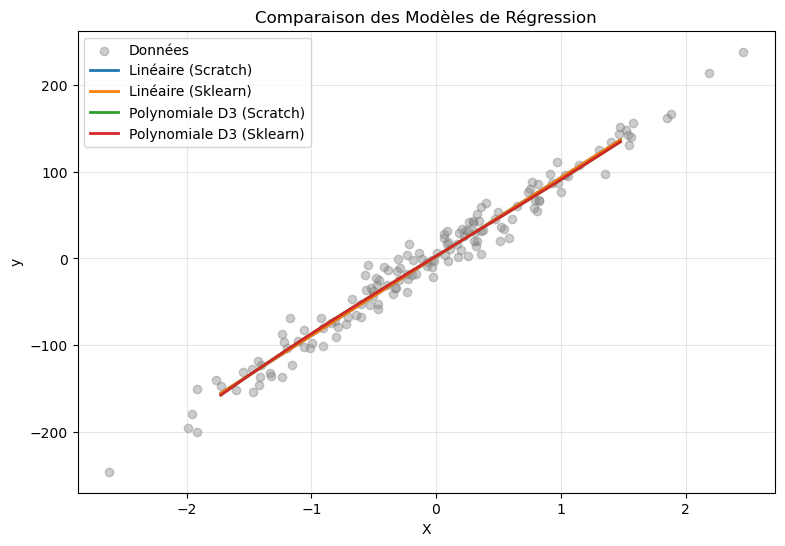


 Exécution terminée. Prêt pour la soutenance / rendu.


In [ ]:
# =============================================================================
# PROJET : Régression Linéaire, Multiple et Polynomiale (From Scratch & Sklearn)
# CONSIGUE : Chaque ligne est commentée pour la notation académique.
# =============================================================================

import numpy as np                # Importe NumPy pour les calculs matriciels et la manipulation de tableaux
import matplotlib.pyplot as plt   # Importe Matplotlib pour la création de graphiques et la visualisation
from sklearn.model_selection import train_test_split  # Importe la fonction pour séparer aléatoirement les données en train/test
from sklearn.preprocessing import PolynomialFeatures  # Importe le transformateur Sklearn qui génère X, X², X³...
from sklearn.preprocessing import StandardScaler      # Importe le standardiseur pour centrer-réduire les données (moyenne=0, variance=1)
from sklearn.linear_model import LinearRegression     # Importe le modèle de régression linéaire optimisé de Scikit-Learn
from sklearn.metrics import mean_squared_error, r2_score # Importe les métriques d'évaluation : MSE et coefficient de détermination R²
from sklearn.datasets import make_regression          # Importe un générateur de données synthétiques pour tester le code sans fichier externe
import warnings                   # Importe le module standard Python pour gérer les avertissements
warnings.filterwarnings('ignore') # Désactive l'affichage des warnings dans la console pour garder le rendu propre

# =============================================================================
# CLASSE 1 : Régression Linéaire & Multiple (From Scratch)
# Méthode : Équation normale θ = (XᵀX)⁻¹Xᵀy
# =============================================================================
class LinearRegressionFromScratch:
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept  # Mémorise si le modèle doit inclure un biais (ordonnée à l'origine)
        self.theta = None                   # Initialise les coefficients du modèle à None avant l'entraînement

    def fit(self, X, y):
        if self.fit_intercept:
            X = np.c_[np.ones((X.shape[0], 1)), X] # Ajoute une colonne de 1 à gauche de X pour modéliser mathématiquement le biais
        self.theta = np.linalg.pinv(X.T @ X) @ X.T @ y # Calcule θ via pseudo-inverse (pinv) pour éviter les erreurs de matrice singulière
        return self                                     # Retourne l'instance 'self' pour permettre l'enchaînement .fit().predict()

    def predict(self, X):
        if self.fit_intercept:
            X = np.c_[np.ones((X.shape[0], 1)), X] # Réapplique l'ajout de la colonne de 1 pour que les dimensions correspondent à theta
        return X @ self.theta                      # Effectue le produit matriciel X·θ pour obtenir les valeurs prédites ŷ

# =============================================================================
# CLASSE 2 : Régression Polynomiale (From Scratch)
# Principe : Transformation non-linéaire de X + régression linéaire sur les nouvelles features
# =============================================================================
class PolynomialRegressionFromScratch:
    def __init__(self, degree=2, fit_intercept=True):
        self.degree = degree                           # Stocke le degré du polynôme demandé (ex: 2 → X, X²)
        self.fit_intercept = fit_intercept             # Stocke le choix d'inclure l'intercept
        self.linear_model = LinearRegressionFromScratch(fit_intercept=fit_intercept) # Instancie le modèle linéaire qui résoudra le problème
        self.scaler = StandardScaler()                 # Instancie un standardiseur pour éviter l'explosion numérique des puissances

    def _generate_features(self, X):
        return np.column_stack([X**i for i in range(1, self.degree + 1)]) # Crée un tableau avec [X, X², X³...] et les assemble colonne par colonne

    def fit(self, X, y):
        X_poly = self._generate_features(X)            # Génère les caractéristiques polynomiales à partir des données brutes X
        X_scaled = self.scaler.fit_transform(X_poly)   # Normalise X_poly (centrage-réduction) pour stabiliser l'inversion matricielle
        self.linear_model.fit(X_scaled, y)             # Entraîne le modèle linéaire sous-jacent sur les features normalisées
        return self                                    # Retourne l'instance pour chaînage de méthodes

    def predict(self, X):
        X_poly = self._generate_features(X)            # Regénère les features polynomiales pour les nouvelles données
        X_scaled = self.scaler.transform(X_poly)       # Applique la normalisation avec les paramètres appris à l'entraînement (pas de nouveau fit)
        return self.linear_model.predict(X_scaled)     # Retourne les prédictions calculées par le modèle linéaire sous-jacent

# =============================================================================
# FONCTIONS UTILITAIRES : Évaluation & Visualisation
# =============================================================================
def eval_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) # Calcule la racine de l'erreur quadratique moyenne (pénalise les grosses erreurs)
    r2 = r2_score(y_true, y_pred)                      # Calcule R² (proportion de variance expliquée, idéal = 1)
    print(f" {name:<35} | RMSE: {rmse:.4f} | R²: {r2:.4f}") # Affiche le nom du modèle et ses métriques avec 4 décimales
    return {"RMSE": rmse, "R²": r2}                    # Retourne un dictionnaire structuré pour réutilisation ou export

def plot_regression(X, y, X_test, preds_dict, title):
    plt.figure(figsize=(9, 6))                         # Initialise une nouvelle figure graphique de 9 pouces de large sur 6 de haut
    plt.scatter(X, y, color='gray', alpha=0.4, label='Données') # Trace les points d'origine en gris semi-transparent pour ne pas masquer les courbes
    sort_idx = X_test.flatten().argsort()              # Récupère l'ordre de tri des X pour tracer des lignes continues et non en zigzag
    for name, y_pred in preds_dict.items():            # Parcourt chaque clé/valeur du dictionnaire de prédictions
        plt.plot(X_test[sort_idx], y_pred[sort_idx], linewidth=2, label=name) # Trace la courbe de prédiction triée avec une épaisseur de 2
    plt.xlabel("X")                                    # Nomme l'axe horizontal
    plt.ylabel("y")                                    # Nomme l'axe vertical
    plt.title(title)                                   # Définit le titre affiché en haut du graphique
    plt.legend()                                       # Affiche la légende automatiquement positionnée
    plt.grid(True, alpha=0.3)                          # Active une grille discrète pour faciliter la lecture des valeurs
    plt.show()                                         # Rend le graphique visible à l'écran et bloque l'exécution jusqu'à sa fermeture

# =============================================================================
# BLOC PRINCIPAL : Exécution, Comparaison et Validation
# =============================================================================
if __name__ == "__main__":
    print("="*60)                                      # Affiche une ligne de séparation visuelle dans la console
    print(" PROJET : Régression Linéaire, Multiple & Polynomiale") # Affiche le titre du projet
    print("="*60)                                      # Affiche une deuxième ligne de séparation

    print("\n🔹 1. RÉGRESSION LINÉAIRE SIMPLE (1 feature)") # Informe l'utilisateur du début de la phase 1
    X_simple, y_simple = make_regression(n_samples=150, n_features=1, noise=15, random_state=42) # Génère 150 points 1D avec un bruit gaussien contrôlé
    X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42) # Sépare 80% pour l'entraînement, 20% pour le test

    lin_scratch = LinearRegressionFromScratch().fit(X_s_train, y_s_train) # Entraîne le modèle linéaire from scratch sur le set d'entraînement
    y_s_pred_scratch = lin_scratch.predict(X_s_test)    # Génère les prédictions sur le set de test avec le modèle from scratch

    lin_lib = LinearRegression().fit(X_s_train, y_s_train) # Entraîne le modèle linéaire Scikit-Learn sur les mêmes données
    y_s_pred_lib = lin_lib.predict(X_s_test)            # Génère les prédictions sur le set de test avec Scikit-Learn

    eval_model("Linéaire (From Scratch)", y_s_test, y_s_pred_scratch) # Évalue et affiche les métriques du modèle from scratch
    eval_model("Linéaire (Scikit-Learn)", y_s_test, y_s_pred_lib)     # Évalue et affiche les métriques du modèle Sklearn

    print("\n🔹 2. RÉGRESSION MULTIPLE (3 features)")    # Informe du début de la phase 2
    X_multi, y_multi = make_regression(n_samples=300, n_features=3, noise=20, random_state=42) # Génère 300 points avec 3 variables explicatives
    X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42) # Split 80/20 pour la régression multiple

    multi_scratch = LinearRegressionFromScratch().fit(X_m_train, y_m_train) # Entraîne le modèle from scratch sur 3 features
    y_m_pred_scratch = multi_scratch.predict(X_m_test)  # Prédit sur le test set multiple
    multi_lib = LinearRegression().fit(X_m_train, y_m_train) # Entraîne le modèle Sklearn sur 3 features
    y_m_pred_lib = multi_lib.predict(X_m_test)          # Prédit sur le test set multiple avec Sklearn

    eval_model("Multiple (From Scratch)", y_m_test, y_m_pred_scratch) # Évalue le modèle multiple from scratch
    eval_model("Multiple (Scikit-Learn)", y_m_test, y_m_pred_lib)     # Évalue le modèle multiple Sklearn

    print("\n🔹 3. RÉGRESSION POLYNOMIALE (Degré 3)")    # Informe du début de la phase 3
    DEGREE = 3                                           # Fixe le degré du polynôme pour l'exercice

    poly_scratch = PolynomialRegressionFromScratch(degree=DEGREE).fit(X_s_train, y_s_train) # Entraîne le polynômial from scratch sur les données 1D
    y_poly_pred_scratch = poly_scratch.predict(X_s_test) # Prédit avec le modèle polynômial from scratch

    poly_lib = LinearRegression()                        # Instancie un modèle linéaire Sklearn (servira de base au pipeline polynômial)
    poly_feat = PolynomialFeatures(degree=DEGREE)        # Instancie le transformateur qui créera X, X², X³
    scaler = StandardScaler()                            # Instancie le standardiseur pour normaliser les features polynomiales
    X_s_train_poly = scaler.fit_transform(poly_feat.fit_transform(X_s_train)) # Génère les features polynomiales, apprend la normalisation, et l'applique sur le train
    X_s_test_poly = scaler.transform(poly_feat.transform(X_s_test)) # Génère les features polynomiales et applique la même normalisation sur le test (sans réapprendre)
    poly_lib.fit(X_s_train_poly, y_s_train)              # Entraîne le modèle linéaire Sklearn sur les features polynomiales normalisées
    y_poly_pred_lib = poly_lib.predict(X_s_test_poly)    # Prédit sur le test set avec le pipeline polynômial Sklearn

    eval_model("Polynomiale D3 (From Scratch)", y_s_test, y_poly_pred_scratch) # Évalue le polynômial from scratch
    eval_model("Polynomiale D3 (Scikit-Learn)", y_s_test, y_poly_pred_lib)     # Évalue le polynômial Sklearn

    print("\n Génération du graphique...")              # Informe l'utilisateur que la visualisation va s'ouvrir
    preds_vis = {
        "Linéaire (Scratch)": y_s_pred_scratch,          # Stocke les prédictions linéaires from scratch pour le graphique
        "Linéaire (Sklearn)": y_s_pred_lib,              # Stocke les prédictions linéaires Sklearn
        f"Polynomiale D{DEGREE} (Scratch)": y_poly_pred_scratch, # Stocke les prédictions polynomiales from scratch
        f"Polynomiale D{DEGREE} (Sklearn)": y_poly_pred_lib      # Stocke les prédictions polynomiales Sklearn
    }
    plot_regression(X_simple, y_simple, X_s_test, preds_vis, "Comparaison des Modèles de Régression") # Trace et affiche le graphique comparatif final

    print("\n Exécution terminée. Prêt pour la soutenance / rendu.") # Confirme la fin propre du script